In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import kruskal
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\utente\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# =========================
# CONFIG
# =========================
pkl_folder = r"C:\Users\utente\Documents\UniTrento\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Hypothesis_Testing\LiquidAI-LFM2-1.2B"

ALPHA           = 0.05
NORMALIZE_TOKENS = True

KEY_FILE_MAP = {
    'How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion':            'Vaccine_Op',
    'How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary':  'Vaccine_RS',
    'How to manage and dealing with fake content on social media.|||opinion':                              'fakeNews_Op',
    'How to manage and dealing with fake content on social media.|||reasoning_summary':                    'fakeNews_RS',
    'What is the gender gap in science? Should we address it? And how?|||opinion':                         'genderGap_Op',
    'What is the gender gap in science? Should we address it? And how?|||reasoning_summary':               'genderGap_RS',
    'What is stereotype threat in STEM? Should we address it? And how?|||opinion':                         'stereotypeThreat_Op',
    'What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary':               'stereotypeThreat_RS',
}

topic_keywords = {
    'How to manage and dealing with discussions about healthcare and COVID vaccines.':
        ['vaccine', 'health', 'covid', 'healthcare'],
    'How to manage and dealing with fake content on social media.':
        ['fake', 'social', 'media', 'content'],
    'What is the gender gap in science? Should we address it? And how?':
        ['gender', 'gap', 'science'],
    'What is stereotype threat in STEM? Should we address it? And how?':
        ['stereotype', 'STEM', 'threat']
}

short_labels = {
    'How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion':           'Vaccine\nOpinion',
    'How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary': 'Vaccine\nReasoning',
    'How to manage and dealing with fake content on social media.|||opinion':                             'FakeNews\nOpinion',
    'How to manage and dealing with fake content on social media.|||reasoning_summary':                   'FakeNews\nReasoning',
    'What is the gender gap in science? Should we address it? And how?|||opinion':                        'GenderGap\nOpinion',
    'What is the gender gap in science? Should we address it? And how?|||reasoning_summary':              'GenderGap\nReasoning',
    'What is stereotype threat in STEM? Should we address it? And how?|||opinion':                        'Stereotype\nOpinion',
    'What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary':              'Stereotype\nReasoning',
}

topic_groups = {
    'COVID Vaccines\n& Healthcare': [
        'How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion',
        'How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary',
    ],
    'Fake Content\non Social Media': [
        'How to manage and dealing with fake content on social media.|||opinion',
        'How to manage and dealing with fake content on social media.|||reasoning_summary',
    ],
    'Gender Gap\nin Science': [
        'What is the gender gap in science? Should we address it? And how?|||opinion',
        'What is the gender gap in science? Should we address it? And how?|||reasoning_summary',
    ],
    'Stereotype\nThreat in STEM': [
        'What is stereotype threat in STEM? Should we address it? And how?|||opinion',
        'What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary',
    ],
}

IBM_BLUE   = '#2E86C1'
IBM_ORANGE = '#E67E22'
C_SIG      = '#C0392B'


def normalize_token(t: str) -> str:
    return t.strip().lower() if NORMALIZE_TOKENS else t.strip()


def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

In [11]:
# =========================
# LOAD PKL FILES
# =========================
topic_layer_vertices = {}

for key, filename in KEY_FILE_MAP.items():
    pkl_file = Path(pkl_folder) / f'{filename}.pkl'
    if not pkl_file.exists():
        print(f'  WARNING: File not found → {pkl_file.name}')
        continue
    topic_layer_vertices[key] = pd.read_pickle(pkl_file)
    print(f'  Loaded → {pkl_file.name}  shape={topic_layer_vertices[key].shape}')

print(f'\nLoaded {len(topic_layer_vertices)} keys')

  Loaded → Vaccine_Op.pkl  shape=(5622, 3)
  Loaded → Vaccine_RS.pkl  shape=(3444, 3)
  Loaded → fakeNews_Op.pkl  shape=(6874, 3)
  Loaded → fakeNews_RS.pkl  shape=(3465, 3)
  Loaded → genderGap_Op.pkl  shape=(5003, 3)
  Loaded → genderGap_RS.pkl  shape=(3085, 3)
  Loaded → stereotypeThreat_Op.pkl  shape=(5062, 3)
  Loaded → stereotypeThreat_RS.pkl  shape=(3292, 3)

Loaded 8 keys


In [12]:
# =========================
# KRUSKAL-WALLIS TESTS
# =========================
LAYER_COLUMNS = {'opinion': 'opinion_Edge', 'reasoning_summary': 'reasoning_summary_Edge'}

kw_results = {}

for topic, keywords in topic_keywords.items():
    topic_words = set(normalize_token(w) for w in topic.replace('?', '').replace('.', '').split())
    exclude     = stop_words | topic_words | set(k.lower() for k in keywords)

    for layer in LAYER_COLUMNS.keys():
        key = f'{topic}|||{layer}'
        if key not in topic_layer_vertices:
            continue

        df = topic_layer_vertices[key]

        mask_kw = df['vertex'].isin([k.lower() for k in keywords])
        list2   = [d for dl in df[mask_kw]['degree_list'] for d in dl]

        mask_other = ~df['vertex'].isin(exclude)
        list1      = [d for dl in df[mask_other]['degree_list'] for d in dl]

        if len(list1) < 2 or len(list2) < 2:
            print(f'  Not enough data: {key}')
            continue

        stat, p = kruskal(list1, list2)

        kw_results[key] = {
            'median_list1': np.median(list1),
            'median_list2': np.median(list2),
            'H':            stat,
            'p':            p,
            'reject':       p < ALPHA,
        }
        print(f'{key}')
        print(f'  median_list1={np.median(list1):.2f}, median_list2={np.median(list2):.2f}, H={stat:.4f}, p={p:.4f}')

How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion
  median_list1=5.00, median_list2=5.00, H=197.1995, p=0.0000
How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary
  median_list1=5.00, median_list2=3.00, H=6179.3229, p=0.0000
How to manage and dealing with fake content on social media.|||opinion
  median_list1=6.00, median_list2=8.00, H=4219.9259, p=0.0000
How to manage and dealing with fake content on social media.|||reasoning_summary
  median_list1=6.00, median_list2=3.00, H=6857.6983, p=0.0000
What is the gender gap in science? Should we address it? And how?|||opinion
  median_list1=6.00, median_list2=14.00, H=16018.5343, p=0.0000
What is the gender gap in science? Should we address it? And how?|||reasoning_summary
  median_list1=6.00, median_list2=3.00, H=5759.8470, p=0.0000
What is stereotype threat in STEM? Should we address it? And how?|||opinion
  median_list1=6.00, median_list2=19.00, H=1855

Figure saved to: C:\Users\utente\Documents\UniTrento\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Hypothesis_Testing\LiquidAI-LFM2-1.2B\kruskal_grouped_plot.png


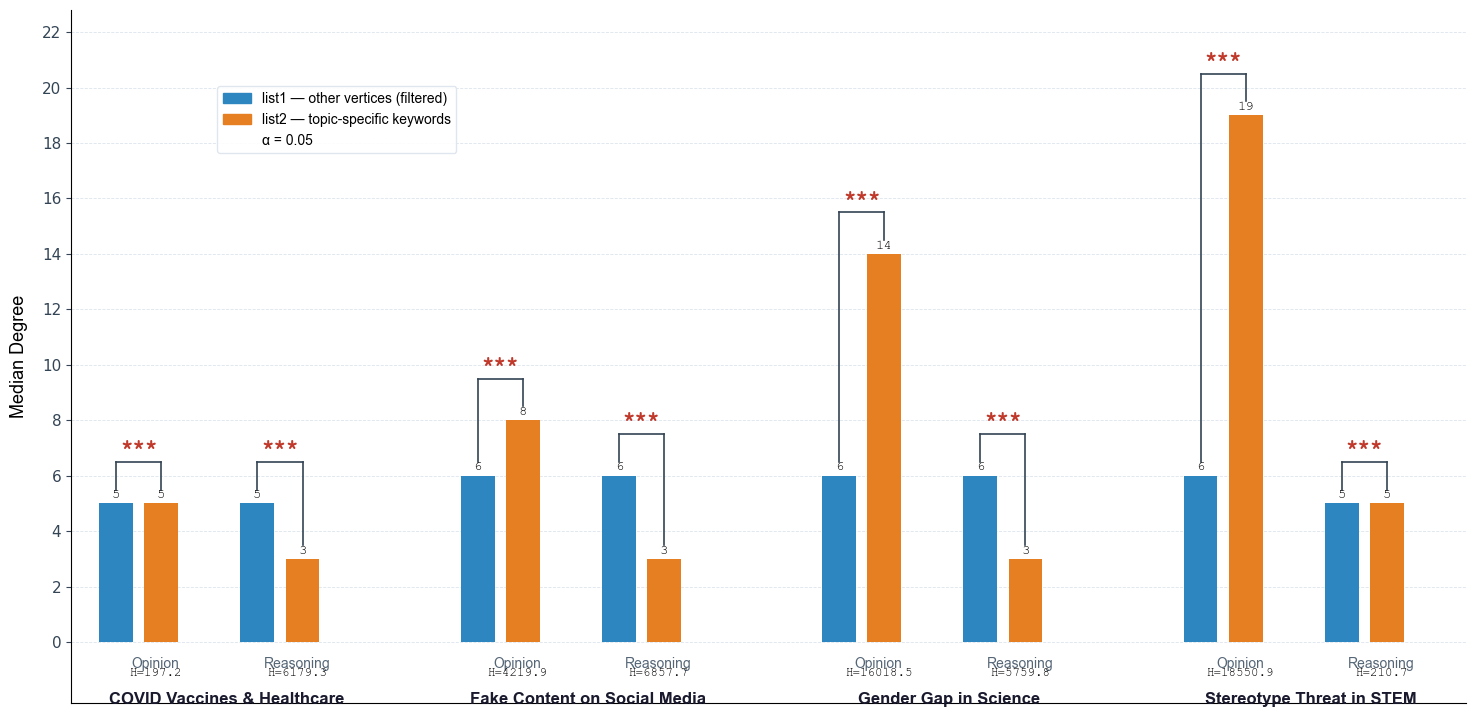

In [13]:
# =========================
# PLOT
# =========================
bar_w     = 0.30
pair_gap  = 0.10
group_gap = 0.70

x_centers        = []
x                = 0.0
group_boundaries = []

for t_label, group_keys in topic_groups.items():
    g_start = x
    for key in group_keys:
        if key not in kw_results:
            continue
        x_centers.append((key, x))
        x += bar_w * 2 + pair_gap + 0.55
    g_end = x - 0.55
    group_boundaries.append((g_start, g_end, t_label))
    x += group_gap

fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

all_medians = []
for key, _ in x_centers:
    all_medians += [kw_results[key]['median_list1'], kw_results[key]['median_list2']]
y_max = max(all_medians) * 1.2

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#dde4ec', zorder=0)
ax.set_axisbelow(True)

for key, xc in x_centers:
    r  = kw_results[key]
    m1 = r['median_list1']
    m2 = r['median_list2']

    x1 = xc
    x2 = xc + bar_w + pair_gap

    ax.bar(x1, m1, width=bar_w, color=IBM_BLUE,   zorder=3, linewidth=0)
    ax.bar(x2, m2, width=bar_w, color=IBM_ORANGE, zorder=3, linewidth=0)

    ax.text(x1, m1 + 0.08, f'{m1:.0f}', ha='center', va='bottom',
            fontsize=10, color='#000000', fontfamily='Courier New')
    ax.text(x2, m2 + 0.08, f'{m2:.0f}', ha='center', va='bottom',
            fontsize=10, color='#000000', fontfamily='Courier New')

    y_left  = m1 + 0.5
    y_right = m2 + 0.5
    y_top   = max(y_left, y_right) + 1

    ax.plot([x1, x1], [y_left,  y_top], color='#334455', lw=1.2)
    ax.plot([x2, x2], [y_right, y_top], color='#334455', lw=1.2)
    ax.plot([x1, x2], [y_top,   y_top], color='#334455', lw=1.2)

    ax.text((x1 + x2) / 2, y_top + 0.1, sig_label(r['p']),
            ha='center', va='bottom', fontsize=15,
            color=C_SIG, fontweight='bold', fontfamily='Courier New')

    sub = short_labels.get(key, key).split('\n')[1]
    ax.text(xc + bar_w + pair_gap / 2, -0.55, sub,
            ha='center', va='top', fontsize=10,
            color='#556677', fontfamily='Arial')

    ax.text(xc + bar_w + pair_gap / 2, -0.95, f"H={r['H']:.1f}",
            ha='center', va='top', fontsize=9,
            color='#000000', fontfamily='Courier New')

header_y = -1.8
for g_start, g_end, label in group_boundaries:
    cx = (g_start + g_end) / 2
    ax.text(cx, header_y, label.replace('\n', ' '),
            ha='center', va='top', fontsize=12,
            fontweight='bold', color='#1a1a2e', fontfamily='Arial')

ax.set_xlim(-0.4, max(xc for _, xc in x_centers) + bar_w * 2 + 0.5)
ax.set_ylim(-2.2, y_max)
ax.set_ylabel('Median Degree', fontsize=13, fontfamily='Arial', color='#000000', labelpad=10)
ax.set_xlabel('')
ax.set_xticks([])

y_ticks = np.arange(0, int(y_max) + 1, 2)
ax.set_yticks(y_ticks)
ax.tick_params(axis='y', labelsize=11, colors='#334455')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_color('#000000')

p1 = mpatches.Patch(color=IBM_BLUE,   label='list1 — other vertices (filtered)')
p2 = mpatches.Patch(color=IBM_ORANGE, label='list2 — topic-specific keywords')
p3 = mpatches.Patch(color='none',     label=f'α = {ALPHA}')
ax.legend(handles=[p1, p2, p3], loc='upper left', bbox_to_anchor=(0.1, 0.9),
          fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dde4ec',
          prop={'family': 'Arial'})

save_path = Path(pkl_folder) / 'kruskal_grouped_plot.png'
plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
print(f'Figure saved to: {save_path}')
plt.show()